# Hantavirus Sentiment and Topic Analysis 
This code will complete overall sentiment and topic analysis for BlueSky data on the hantavirus 

---
### Libraries & Data
This section of code imports the required libraries to be able to run the code and also imports the Hantavirus data from BlueSky.

In [1]:
#Libraries to be imported
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sys
import string
import re
import nltk
import codecs
import emoji
import gensim
import random
import numpy as np
from datetime import datetime, date, timedelta
from collections import Counter
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer 
from nltk import bigrams
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import DetectorFactory
from gensim.models import CoherenceModel
from gensim.models import LdaModel
from wordcloud import WordCloud
from gensim import corpora
from collections import defaultdict
from nrclex import NRCLex
from collections import Counter
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /Users/hazelkok/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
#Import the data
df = pd.read_csv("Data/Bluesky_dataset_UG11.csv")

In [3]:
#Convert the post date to the correct format
df['created_at'] = pd.to_datetime(df['created_at'],format='ISO8601')

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_64425/2647329625.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['created_at'] = pd.to_datetime(df['created_at'],format='ISO8601')


----
### Sentiment analysis - Overall data
This section will conduct sentiment analysis on all the BlueSky data combined, for an overview of public perception on the outbreak over time.

In [4]:
#Gather a list of posts made
hanta_posts = []

for row in df.itertuples(index=False):
    post_author = row.author
    post_text = row.text
    post_date = row.created_at
    post_likes = row.likes
    post_reposts = row.reposts

    hanta_posts.append([post_author, post_text, post_date, post_likes, post_reposts])

In [5]:
#Code adapted from: https://medium.com/@monigrancharov/text-language-detection-with-python-beb49d9667b3 & https://pypi.org/project/langdetect/
#Method to detect the langauge of the comments
def detect_language_analysis(text): 
    try: 
        language = detect(text) 
        return language #Return language if detected

    except: return "Unknown" #Return unknown if language not known - example small sentances

In [6]:
#Get a count for each language in the dataset
#To be put into a table in the final report
language_count = Counter() #Set up a counter to count all the languages
Lan_date = [] #List to hold the date of the comments
English_posts = [] #List of English comments - to be used for rest of analysis
DetectorFactory.seed = 0 #Detecting languages can give different results, we set a seed to ensure consistency when code is run again

#Detecting the languages from the comments
for post_author, post_text, post_date, post_likes, post_reposts in hanta_posts:
    language = detect_language_analysis(post_text)
    language_count.update([language]) #Update the counter with language
    Lan_date.append([post_date, language]) #Append date and language to Lan_date
    if language == 'en':
        English_posts.append([post_author, post_date, post_text, post_likes, post_reposts]) #Only if the language is English append to the english list

language_count #Print the count of languages to be used in table in report

Counter({'en': 14387,
         'cy': 9,
         'fr': 7,
         'de': 6,
         'af': 5,
         'tl': 4,
         'nl': 4,
         'cs': 3,
         'et': 3,
         'sv': 2,
         'so': 2,
         'it': 2,
         'fi': 2,
         'id': 2,
         'pl': 2,
         'ca': 2,
         'da': 2,
         'es': 1,
         'no': 1,
         'ro': 1,
         'sl': 1,
         'pt': 1,
         'sk': 1,
         'sq': 1})

In [7]:
#Code adapted from Week 3/4 Workshop code (data processing)
#Code adapted from https://stackoverflow.com/questions/15586721/wordnet-lemmatization-and-pos-tagging-in-python (POS tagging approach to Lemmas)
#Method to process text for N-Grams analysis
def processText(text, tokenizer, Lemma, stopwords):

    #Method to pos tagging words to improve lemmatization
    def get_wordnet_pos(treebank_tag):

        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.VERB

    #Convert all to lower case
    text = text.lower()

    #Tokenise
    lTokens = tokenizer.tokenize(text) 
    #Strip whitespaces before and after
    lTokens = [token.strip() for token in lTokens]

     #POS tagging
    pos_tag_token = nltk.pos_tag(lTokens)

    #Lemmatization
    lStemmedTokens = [Lemma.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in pos_tag_token]

    #Remove stopwords, digits, emojis
    return [tok for tok in lStemmedTokens if tok not in stopwords and tok.isalpha()]

#Number of most frequent terms to display
freqNum = 50

#Tokeniser (TweetTokenizer works well for social media text in general)
tweetTokeniser = nltk.tokenize.TweetTokenizer()
#Punctuation list
lPunct = list(string.punctuation)
#Stopwords
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via']
#Lemmatizer
lemmatizer = WordNetLemmatizer()
#Term frequency counter
termFreqCounter = Counter()
HV_Token_posts = []

#Process each english comment
for post_author, post_date, post_text, post_likes, post_reposts in English_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    #Update term frequency
    termFreqCounter.update(lTokens)
    HV_Token_posts.append(lTokens) 

In [8]:
#Print Unigram term frequencies
termFreqCounter 

Counter({'hantavirus': 2298,
         'ship': 1713,
         'cruise': 1640,
         'people': 1486,
         'get': 1115,
         'outbreak': 1108,
         'go': 1082,
         'like': 1048,
         'covid': 958,
         'know': 947,
         'say': 927,
         'one': 918,
         'virus': 906,
         'us': 728,
         'think': 723,
         'would': 678,
         'spread': 676,
         'health': 673,
         'trump': 654,
         'passenger': 632,
         'time': 598,
         'case': 542,
         'take': 530,
         'make': 528,
         'quarantine': 516,
         'human': 509,
         'good': 506,
         'need': 485,
         'pandemic': 459,
         'see': 450,
         'thing': 447,
         'news': 438,
         'contact': 437,
         'public': 424,
         'cdc': 424,
         'also': 423,
         'disease': 415,
         'well': 412,
         'person': 410,
         'could': 404,
         'day': 384,
         'right': 380,
         'die': 374,
     

In [9]:
#Code adapted from: https://www.geeksforgeeks.org/nlp/generate-bigrams-with-nltk/
biFreqCounter = Counter() #Counter for Bigrams
Bi_gram_comments = [] #List to hold Bigram comments

#Get all bigrams and append to counter and list
for comment in HV_Token_posts:
    comment_bigrams = list(bigrams(comment))
    Bi_gram_comments.append(comment_bigrams)
    biFreqCounter.update(comment_bigrams)

#Print Bigram term frequencies
biFreqCounter 

Counter({('cruise', 'ship'): 1050,
         ('hantavirus', 'outbreak'): 471,
         ('public', 'health'): 261,
         ('rfk', 'jr'): 223,
         ('human', 'human'): 156,
         ('mv', 'hondius'): 139,
         ('test', 'positive'): 134,
         ('hantavirus', 'cruise'): 132,
         ('incubation', 'period'): 115,
         ('close', 'contact'): 109,
         ('andes', 'virus'): 102,
         ('go', 'cruise'): 90,
         ('person', 'person'): 88,
         ('penile', 'implant'): 82,
         ('sound', 'like'): 82,
         ('look', 'like'): 82,
         ('petri', 'dish'): 82,
         ('infectious', 'disease'): 78,
         ('andes', 'strain'): 78,
         ('andes', 'hantavirus'): 75,
         ('like', 'covid'): 73,
         ('people', 'die'): 72,
         ('outbreak', 'cruise'): 69,
         ('trump', 'administration'): 66,
         ('health', 'official'): 65,
         ('ship', 'outbreak'): 64,
         ('go', 'wrong'): 61,
         ('wear', 'mask'): 58,
         ('get', 'si

In [10]:
#Methods to clean posts to be able tocalculate Vader Sentiment
#Cleaning Text
def clean_for_sentiment(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

#Pre-processing text including tokenisation, stop word removal and whitespace removal.
def processTextSA(text, tokenizer, stopwords):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    tokens = [token.strip() for token in tokens]
    return [token for token in tokens
            if token not in stopwords
            and not token.isdigit()
            and token.isalpha()]

tweetTokeniser = nltk.tokenize.TweetTokenizer()
lPunct = list(string.punctuation)
custom_stopwords = ['via', 'rt', '...', '…', '"', "'", '`']
lStopwords = set(nltk.corpus.stopwords.words('english') + lPunct + custom_stopwords)

In [11]:
#Code adapted from Week 4 Workshop code 
#Use Vader lexicons instead of a raw positive and negative word count.
def vaderSentimentAnalysis(comments, bPrint):

    #This is the vader sentiment analyser, part of nltk
    sentAnalyser = SentimentIntensityAnalyzer()

    comments_pro = comments #Getting our pre-processed comments
    lSentiment = [] #List to hold sentiment and dates
    # open file and process reddit posts, one by one
    for date,lTokens in comments_pro:
        #This computes the sentiment scores (called polarity score in nltk, but mean same thing essentially)
        dSentimentScores = sentAnalyser.polarity_scores(" ".join(lTokens))

        #Save the date and sentiment of each post (used for time series)
        lSentiment.append([pd.to_datetime(date, unit='s'), dSentimentScores['compound']])

        #If we are printing, we print the tokens then the sentiment scores.  Because we don't have the list of positive and negative words, we cannot use colorama to label each token
        if bPrint:
            vaderPrintTokens(lTokens, dSentimentScores)
                
                           
    return lSentiment #list of comments, in the format of [date, sentiment]

In [12]:
#Code adapted from Week 4 Workshop code 
#We will use the tweet tokenizer as this is good for social media
tweetTokenizer = TweetTokenizer()
lPunct = list(string.punctuation)
#Standard 'English' stopwords plus some other common punctuation
lStopwords = stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`']
flagPrint=False

In [13]:
Sentiment_HV_posts = []

for post_author, post_date, post_text, post_likes, post_reposts in English_posts:
    clean_text = clean_for_sentiment(post_text)   # light clean first

    lTokens = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords)
    Sentiment_HV_posts.append([post_date, lTokens])

In [14]:
lSentimentVDR = [] #To hold returned list of posts with [date,sentiment]
lSentimentVDR = vaderSentimentAnalysis(Sentiment_HV_posts, flagPrint) #Run and caluclate Vader Sentiment analysis

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_64425/1071982004.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  newSeries = series.resample('1H').mean()


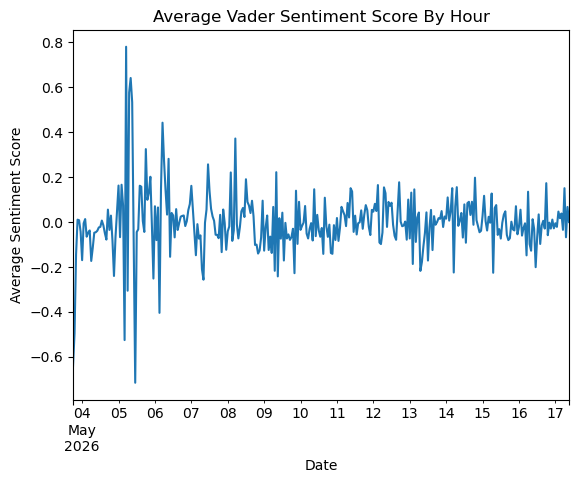

In [15]:
#Code adapted from Week 4 Workshop code 
#Plot Vader mean sentiment scores by date - 1 hour timeframe
#We are using pandas for this, but first we need to get it into a pandas data frame structure
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

#Convert date to the correct format
series['date'] = pd.to_datetime(series['date'], errors='coerce', utc=True)
series['date'] = series['date'].dt.tz_convert(None)

#Tell pandas that the date column is the one we use for indexing (or x-axis)
series.set_index('date', inplace=True)

#Pandas makes a guess at the type of the columns, but to make sure it doesn't get it wrong, we set the sentiment
#Column to floats
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

#Plot to be hourly
#Plot to be mean sentiment score for all comments in that hour
newSeries = series.resample('1H').mean()
#Plot and show the time series
newSeries.plot(legend=False)
plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

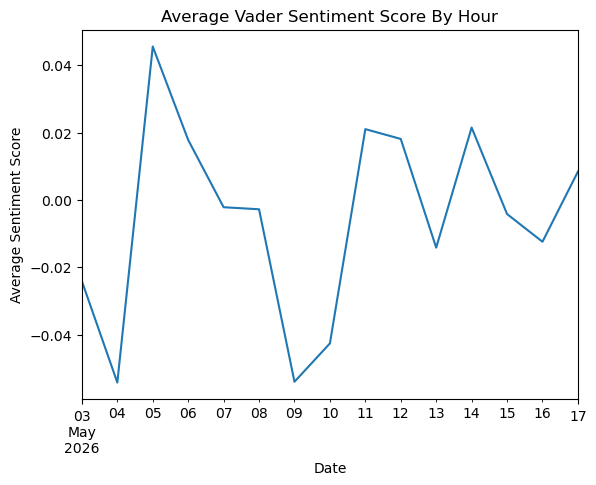

In [16]:
#Code adapted from Week 4 Workshop code 
#Plot Vader mean sentiment scores by date - 1 Day timeframe
#We are using pandas for this, but first we need to get it into a pandas data frame structure
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

#Convert date to the correct format
series['date'] = pd.to_datetime(series['date'], errors='coerce', utc=True)
series['date'] = series['date'].dt.tz_convert(None)

#Tell pandas that the date column is the one we use for indexing (or x-axis)
series.set_index('date', inplace=True)

#Pandas makes a guess at the type of the columns, but to make sure it doesn't get it wrong, we set the sentiment
#Column to floats
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

#Plot to be day
#Plot to be mean sentiment score for all comments in that day
newSeries = series.resample('1D').mean()
#Plot and show the time series
newSeries.plot(legend=False)
plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_64425/609454991.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  newSeries = series.resample('1H').sum()


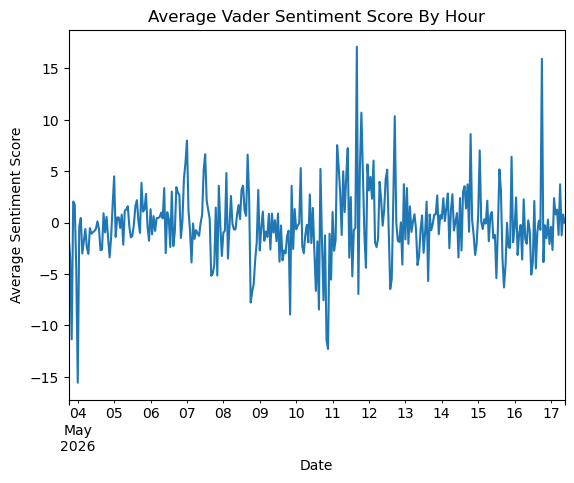

In [17]:
#Code adapted from Week 4 Workshop code 
#Plot Vader mean sentiment scores by date - 1 Day timeframe
#We are using pandas for this, but first we need to get it into a pandas data frame structure
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

#Convert date to the correct format
series['date'] = pd.to_datetime(series['date'], errors='coerce', utc=True)
series['date'] = series['date'].dt.tz_convert(None)

#Tell pandas that the date column is the one we use for indexing (or x-axis)
series.set_index('date', inplace=True)

#Pandas makes a guess at the type of the columns, but to make sure it doesn't get it wrong, we set the sentiment
#Column to floats
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

#Plot to be day
#Plot to be mean sentiment score for all comments in that day
newSeries = series.resample('1H').sum()
#Plot and show the time series
newSeries.plot(legend=False)
plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

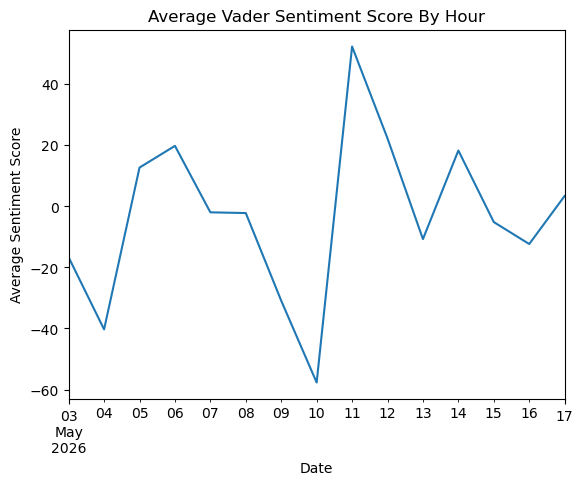

In [18]:
#Code adapted from Week 4 Workshop code 
#Plot Vader mean sentiment scores by date - 1 Day timeframe
#We are using pandas for this, but first we need to get it into a pandas data frame structure
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

#Convert date to the correct format
series['date'] = pd.to_datetime(series['date'], errors='coerce', utc=True)
series['date'] = series['date'].dt.tz_convert(None)

#Tell pandas that the date column is the one we use for indexing (or x-axis)
series.set_index('date', inplace=True)

#Pandas makes a guess at the type of the columns, but to make sure it doesn't get it wrong, we set the sentiment
#Column to floats
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

#Plot to be day
#Plot to be mean sentiment score for all comments in that day
newSeries = series.resample('1D').sum()
#Plot and show the time series
newSeries.plot(legend=False)
plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

---
## Topic Analysis - Overall data
This section will conduct topic analysis (LDA Method) on the entire BlueSky dataset, in order to uncover the topics which are being discussed on the BlueSky platform. This sections topics will also be utilised to group different communities by their dominant topic in future sections of this notebook.

In [19]:
#Code Adapted from https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Method to calculate the coherence scores for k number of topics 
def compute_coherence_values(dictionary, corpus, texts, start=2, limit=10, step=1):
    coherence_values = [] #List to store the coherence scores
    models = [] #List of models
    #Use a seed to ensure reproducability over multiple runs 
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)

    #Train an LDA MODEL for k number of topics between the start and stop value
    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10)
        models.append(model)

        #Calculate the coherence score for each model
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v')

        #Append cohenerence values to the list - to be used in plot
        coherence_values.append(coherencemodel.get_coherence())

    return models, coherence_values

In [20]:
#code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Create a dictionary mapping words to unique IDs from tokenized comments
dictionary = corpora.Dictionary(HV_Token_posts)
#Convert tokenized documents into bag of words (BOW) representation
corpus = [dictionary.doc2bow(doc) for doc in HV_Token_posts]

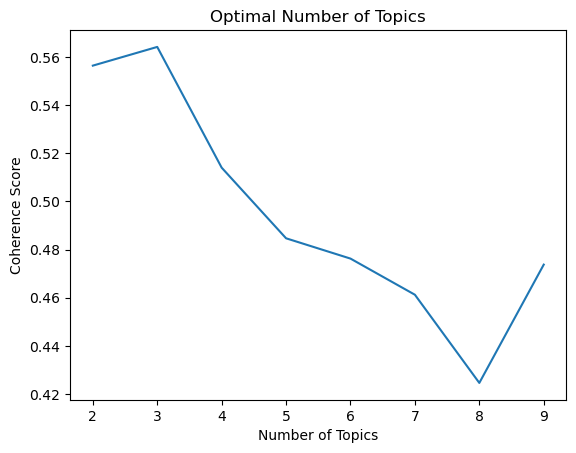

In [21]:
#Code adapted from: https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Run the method from above to calculate the coherence score of the LDA model for different k number of topics
#This code section may be slow to run.
models, coherence_values = compute_coherence_values(dictionary=dictionary,
                                                    corpus=corpus,
                                                    texts=HV_Token_posts,
                                                    start=2,
                                                    limit=10,
                                                    step=1)

#Plot the coherence scores for k number of topics.
x = range(2, 10)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics")
plt.show()

In [22]:
#Code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Train the LDA model with the optimal number of topics
lda_model = LdaModel(corpus, num_topics=3, id2word=dictionary,random_state=42, passes = 5)
#Print the topics
print(lda_model.print_topics())

[(0, '0.016*"hantavirus" + 0.014*"like" + 0.014*"virus" + 0.013*"spread" + 0.010*"human" + 0.010*"rodent" + 0.008*"know" + 0.008*"one" + 0.008*"covid" + 0.007*"person"'), (1, '0.013*"go" + 0.010*"trump" + 0.008*"health" + 0.008*"get" + 0.008*"think" + 0.007*"us" + 0.007*"rfk" + 0.006*"good" + 0.006*"cdc" + 0.006*"public"'), (2, '0.048*"ship" + 0.046*"cruise" + 0.031*"hantavirus" + 0.025*"outbreak" + 0.018*"people" + 0.014*"passenger" + 0.012*"three" + 0.010*"die" + 0.008*"say" + 0.008*"suspected"')]


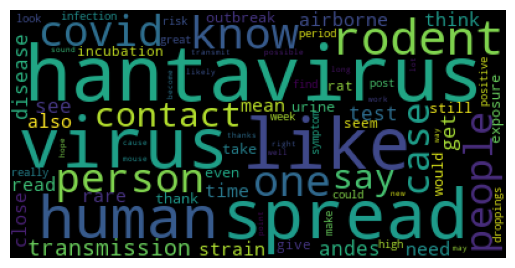

In [23]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 0 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(0, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

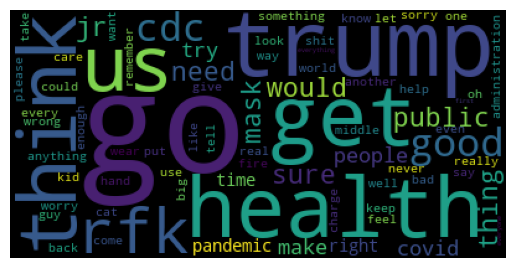

In [24]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 1 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(1, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

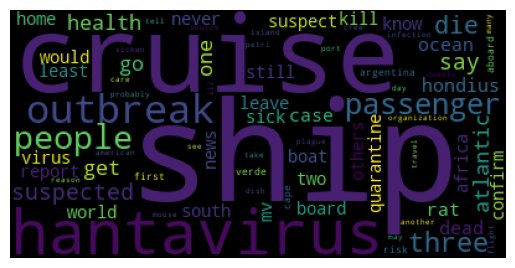

In [25]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 1 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(2, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

---
### Sentiment by Topic 
This section will calculate the sentiment of posts grouped by their dominant topic distribution. It will allow for understanding into how the different topics progress sentiment wise as the outbreak progresses.

In [26]:
#Code adapted from: https://stackoverflow.com/questions/53313575/how-to-get-document-topics-distribution-of-all-of-the-document-in-gensim-lda
#Get the topic distribution for each document
topics_doc = [lda_model.get_document_topics(item) for item in corpus]

#Code adapted from: https://stackoverflow.com/questions/62419353/select-texts-by-topic-lda
#Choose dominant topic with the highest probability for each sentence
top_topic = [max(topics, key=lambda x: x[1])[0] for topics in topics_doc]

In [27]:
#List to store date,sentiment,topic
topic_Sentiment = []

#Extract date,sentiment from lSentimentVDR and add the topic
for i in range(len(lSentimentVDR)):
    d_t = lSentimentVDR[i]
    topic = top_topic[i]
    topic_Sentiment.append(d_t + [topic])

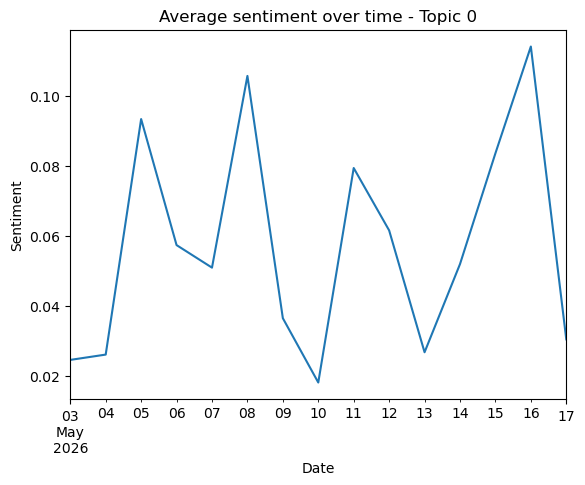

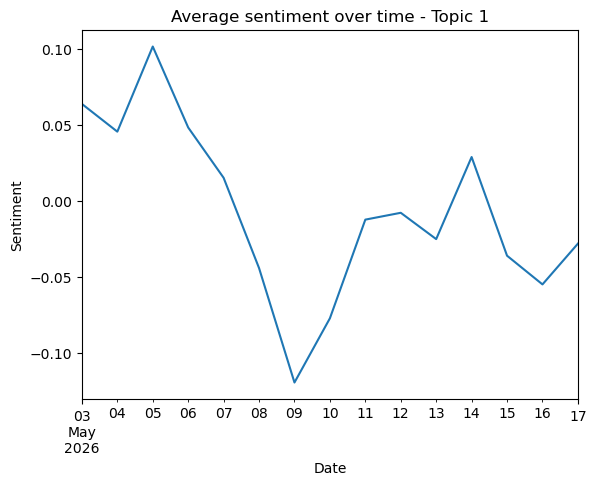

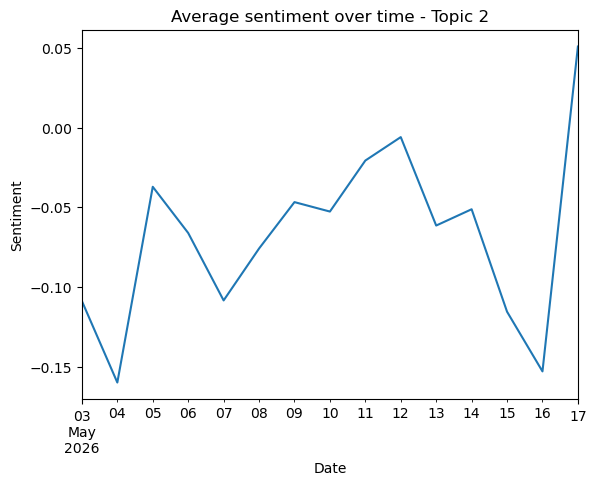

In [28]:
#Code adapted from Week 4 Workshop code 
#Plot Vader sum sentiment scores by date and topic - 1 Day timeframe
#We are using pandas for this, but first we need to get it into a pandas data frame structure
series = pd.DataFrame(topic_Sentiment,columns=['date', 'sentiment', 'topic'])

#Convert dates to the correct form
series['date'] = pd.to_datetime(series['date'], errors='coerce',utc=True)
series['date'] = series['date'].dt.tz_convert(None)

#Pandas makes a guess at the type of the columns, but to make sure it doesn't get it wrong, we set the sentiment
#Column to floats
series.set_index('date', inplace=True)
series['sentiment'] = pd.to_numeric(series['sentiment'])

#Plot each topic (0-2) individually
#Plot topic 0
topic0 = series[series['topic'] == 0]
#Plot to be Day
#Plot to be mean sentiment score for all comments in that Day
newSeries = topic0.resample('1D')['sentiment'].mean()
newSeries.plot(legend=False)
plt.title("Average sentiment over time - Topic 0")
plt.ylabel("Sentiment")
plt.xlabel("Date")
plt.show()

#Plot topic 0
topic1 = series[series['topic'] == 1]
#Plot to be Day
#Plot to be mean sentiment score for all comments in that Day
newSeries = topic1.resample('1D')['sentiment'].mean()
newSeries.plot(legend=False)
plt.title("Average sentiment over time - Topic 1")
plt.ylabel("Sentiment")
plt.xlabel("Date")
plt.show()


#Plot topic 2
topic2 = series[series['topic'] == 2]
#Plot to be Day
#Plot to be mean sentiment score for all comments in that Day
newSeries = topic2.resample('1D')['sentiment'].mean()
newSeries.plot(legend=False)
plt.title("Average sentiment over time - Topic 2")
plt.ylabel("Sentiment")
plt.xlabel("Date")
plt.show()

---
### Grouping Communities by topics
This section will look to see from our original three topics, which is most dominant within a community. Communities will be classified by their dominant topic, seeking insights into wheter communities that for the majority dicuss similar topics have similar sentiment.

In [33]:
#Load the dataset with communities attached
posts_df = pd.read_csv('Data/hanta_posts_with_community.csv')
posts_df['date'] = pd.to_datetime(posts_df['date'], utc=True, errors='coerce')

In [34]:
#Create a list with sentiment and community
#To be able to determine which topics are dominant in which community
topics_doc = [lda_model.get_document_topics(item) for item in corpus]
top_topic  = [max(topics, key=lambda x: x[1])[0] for topics in topics_doc]

topic_Sentiment = []
for i in range(len(lSentimentVDR)):
    d_t   = lSentimentVDR[i] 
    topic = top_topic[i]
    com = posts_df.iloc[i]['community']
    topic_Sentiment.append(d_t + [com, topic])

In [35]:
#Code adapted from: https://stackoverflow.com/questions/53313575/how-to-get-document-topics-distribution-of-all-of-the-document-in-gensim-lda
#Get the topic distribution for each document
topics_doc = [lda_model.get_document_topics(item) for item in corpus]

#Code adapted from: https://stackoverflow.com/questions/62419353/select-texts-by-topic-lda
#Choose dominant topic with the highest probability for each sentence
top_topic = [max(topics, key=lambda x: x[1])[0] for topics in topics_doc]

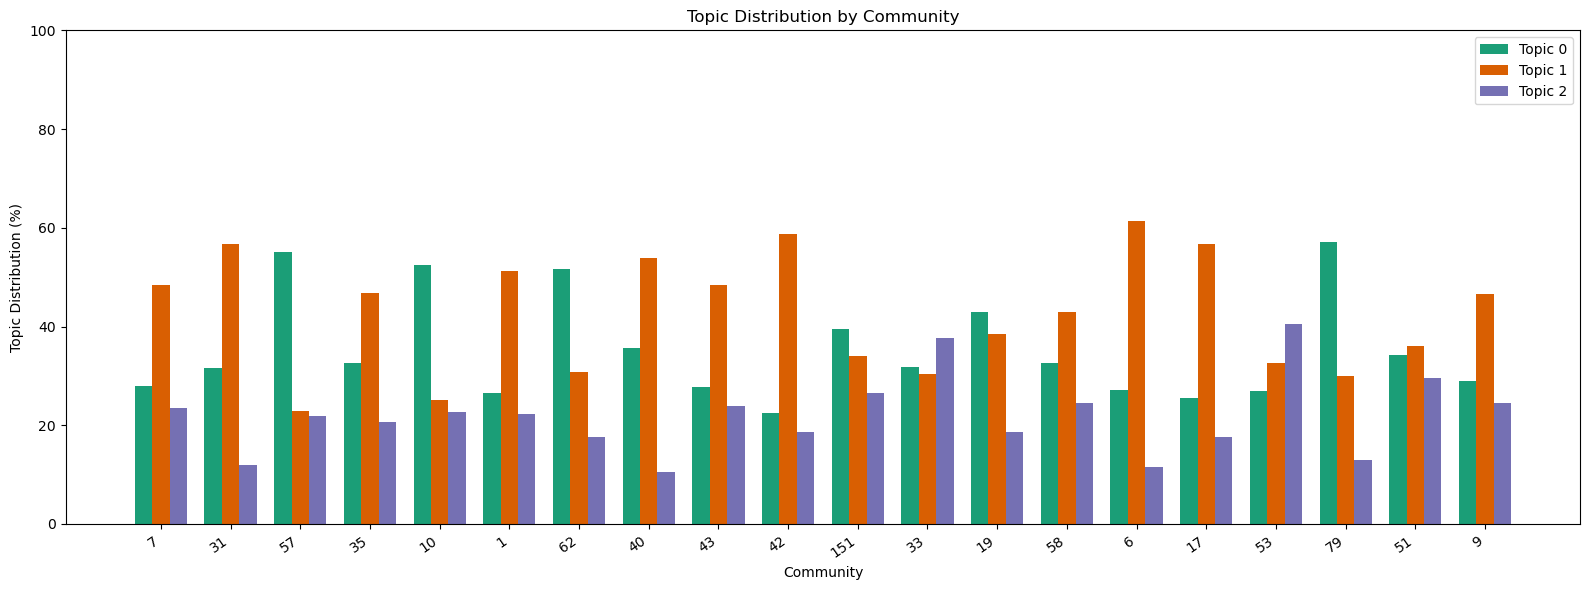

In [36]:
#Code adapted from: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html
#Code to plot the proportions of topics within a community
#To be able to count the number of topics per community
community_topic_dist = defaultdict(lambda: defaultdict(int))

#Get all of the topic counts per community
for date, sentiment, community, topic in topic_Sentiment:
    community_topic_dist[community][topic] += 1

#Top 20 communities that will be looked at
top_20 = [7, 31, 57, 35, 10, 1, 62, 40, 43, 42, 151, 33, 19, 58, 6, 17, 53, 79, 51, 9]

#Lists to store labels and distribution percentages per community
labels = []
topic0_dist, topic1_dist, topic2_dist = [], [], []

#For each community get the topics and compute the percentages
for community in top_20:
    topics = community_topic_dist.get(community)
    total = sum(topics.values())
    labels.append(str(community))
    topic0_dist.append(topics.get(0, 0) / total * 100)
    topic1_dist.append(topics.get(1, 0) / total * 100)
    topic2_dist.append(topics.get(2, 0) / total * 100)

#Plot the graph
x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, topic0_dist, width, label='Topic 0', color='#1b9e77')
ax.bar(x, topic1_dist, width, label='Topic 1', color='#d95f02')
ax.bar(x + width, topic2_dist, width, label='Topic 2', color='#7570b3')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_ylabel('Topic Distribution (%)')
ax.set_xlabel('Community')
ax.set_title('Topic Distribution by Community')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [37]:
#Output the average sentiment score per community type
#Topic labels for each community grouping
topic_des = { 0: 'Topic 0', 1: 'Topic 1', 2: 'Topic 2' }

#Find dominant topic per community
dom_community = {}
for community in top_20:
    topics = community_topic_dist.get(community)
    dom_community[community] = max(topics, key=topics.get)

#Aggregate the results into positive negative and neutral (for percentages)
topic_scores = defaultdict(list)
topic_counts = defaultdict(lambda: {"positive": 0, "neutral": 0, "negative": 0})
for date, sentiment, community, topic in topic_Sentiment:
    if community not in top_20:
        continue

    #Get the dominant topic from the post
    dominant_topic = dom_community.get(community)
    topic_lbl = topic_des[dominant_topic]
    topic_scores[topic_lbl].append(sentiment)

    #Establish wheter the post is positive, negative or neutral
    if sentiment > 0.05:
        topic_counts[topic_lbl]["positive"] += 1
    elif sentiment < -0.05:
        topic_counts[topic_lbl]["neutral"] += 1
    else:
        topic_counts[topic_lbl]["negative"] += 1


#Output the results
for label in topic_des.values():
    scores = topic_scores.get(label, [])
    counts = topic_counts.get(label, {})
    total = sum(counts.values())
    avg_score = np.mean(scores)
    pos_pct = counts.get("positive", 0) / total * 100
    neu_pct = counts.get("neutral", 0) / total * 100
    neg_pct = counts.get("negative", 0) / total * 100
    print(f"{label:<15} {avg_score:<10.3f} {pos_pct:<8.1f} {neu_pct:<8.1f} {neg_pct:<8.1f}")

Topic 0         0.071      43.2     30.9     25.9    
Topic 1         -0.031     33.1     37.4     29.5    
Topic 2         -0.033     30.2     32.9     36.9    


---
### Sentiment by Community
This section will detect the average compound sentiment of each community using the VADER method.

In [38]:
#Output the average compound sentiment scores by each of the top 20 communties
#Gather the sentiment scores (already calculated)
community_sentiments = defaultdict(list)
for date, sentiment, community, topic in topic_Sentiment:
    community_sentiments[community].append(sentiment)

#Output the results
#Only use those communities in the top 20 size
for community in top_20:
    scores = community_sentiments.get(community, [])
    if not scores:
        continue
    avg_sentiment_compound = np.mean(scores)
    print(f"{community:<5} {avg_sentiment_compound:<15.3f}")

7     -0.008         
31    -0.025         
57    0.080          
35    -0.051         
10    0.038          
1     -0.058         
62    0.059          
40    -0.007         
43    -0.058         
42    -0.120         
151   0.027          
33    -0.027         
19    0.035          
58    0.001          
6     -0.017         
17    -0.032         
53    -0.040         
79    0.206          
51    0.005          
9     -0.012         


----
### Sentiment by day (May 4th and 9th)
May 4th and 9th were seen to be the lowest sentiment days for overall data, this section seeks to find the most liked posts and bi-grams which were utilised on these days, to uncover what was being dicussed and why sentiment was so low.

In [39]:
#Code adapted from: https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
#Code adapted from: https://github.com/python/cpython/blob/main/Doc/howto/sorting.rst
#Getting the top posts for Mat 4th and 9th
#These correlate with drops in sentiment
#Estbalish which posts are may 4th and 9th
may4_posts = [p for p in hanta_posts if pd.to_datetime(p[2], utc=True).month == 5 and pd.to_datetime(p[2], utc=True).day == 4]
may9_posts = [p for p in hanta_posts if pd.to_datetime(p[2], utc=True).month == 5 and pd.to_datetime(p[2], utc=True).day == 9]

#Sort by the top liked post
top_may4 = sorted(may4_posts, key=lambda x: x[3], reverse=True)[:1]
top_may9 = sorted(may9_posts, key=lambda x: x[3], reverse=True)[:1]

#Output the most liked posts
for post in top_may4:
    print(post)

for post in top_may9:
    print(post)

['njbbari3.bsky.social', 'Hantavirus is *well known* to spread by the airborne route.\n\nMainly, airborne rodent poop and pee.\n\nCongratulations to all the mainstream media outlets that have already managed to flat out lie about hantavirus transmission.', Timestamp('2026-05-04 07:30:51.663000+0000', tz='UTC'), 357, 132]
['markjacob.bsky.social', '“In the midst of a hantavirus outbreak that involves Americans …  the Centers for Disease Control and Prevention has been uncharacteristically missing in action, according to a number of experts.”', Timestamp('2026-05-09 18:53:21.807000+0000', tz='UTC'), 714, 280]


In [40]:
#Code adapted from: https://www.geeksforgeeks.org/nlp/generate-bigrams-with-nltk/
#Output the top bigrams for may 4
#Listto store tokens
may4_tokens = []

#For each may 4th post get the tokens from the posts
for post_author, post_text, post_date, post_likes, post_reposts in may4_posts:

    #Pre-process and tokenise
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)
    lTokens = processText(text=commentText,
                          tokenizer=tweetTokeniser,
                          Lemma=lemmatizer,
                          stopwords=lStopwords)


    
    may4_tokens.append(lTokens)

#Counter for Bigrams
may4_biFreqCounter = Counter() 
Bi_gram_comments = [] #List to hold Bigram comments

#Get all bigrams and append to counter and list
for comment in may4_tokens:
    comment_bigrams = list(bigrams(comment))
    Bi_gram_comments.append(comment_bigrams)
    may4_biFreqCounter.update(comment_bigrams)

#Print Bigram term frequencies
may4_biFreqCounter 

Counter({('cruise', 'ship'): 148,
         ('hantavirus', 'outbreak'): 34,
         ('three', 'people'): 24,
         ('go', 'cruise'): 18,
         ('people', 'die'): 16,
         ('cape', 'verde'): 16,
         ('suspected', 'hantavirus'): 15,
         ('hantavirus', 'cruise'): 14,
         ('petri', 'dish'): 14,
         ('atlantic', 'ocean'): 14,
         ('ship', 'atlantic'): 13,
         ('mv', 'hondius'): 12,
         ('outbreak', 'cruise'): 12,
         ('suspected', 'outbreak'): 11,
         ('south', 'africa'): 11,
         ('float', 'petri'): 10,
         ('public', 'health'): 8,
         ('know', 'hantavirus'): 8,
         ('outbreak', 'hantavirus'): 8,
         ('suspect', 'hantavirus'): 8,
         ('infected', 'rodent'): 7,
         ('hantavirus', 'rare'): 7,
         ('human', 'human'): 7,
         ('hantavirus', 'infection'): 7,
         ('rfk', 'jr'): 7,
         ('crew', 'member'): 6,
         ('hantavirus', 'pulmonary'): 6,
         ('pulmonary', 'syndrome'): 6,
   

In [41]:
#Code adapted from: https://www.geeksforgeeks.org/nlp/generate-bigrams-with-nltk/
#Output the top bigrams for may 9
#Listto store tokens
may9_tokens = []

#For each may 4th post get the tokens from the posts
for post_author, post_text, post_date, post_likes, post_reposts in may9_posts:

    #Pre-process and tokenise
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)
    lTokens = processText(text=commentText,
                          tokenizer=tweetTokeniser,
                          Lemma=lemmatizer,
                          stopwords=lStopwords)


    
    may9_tokens.append(lTokens)

#Counter for Bigrams
may9_biFreqCounter = Counter() 
Bi_gram_comments = [] #List to hold Bigram comments

#Get all bigrams and append to counter and list
for comment in may9_tokens:
    comment_bigrams = list(bigrams(comment))
    Bi_gram_comments.append(comment_bigrams)
    may9_biFreqCounter.update(comment_bigrams)

#Print Bigram term frequencies
may9_biFreqCounter 

Counter({('cruise', 'ship'): 44,
         ('hantavirus', 'outbreak'): 17,
         ('rfk', 'jr'): 16,
         ('public', 'health'): 13,
         ('hantavirus', 'cruise'): 11,
         ('go', 'wrong'): 7,
         ('person', 'person'): 6,
         ('norovirus', 'cruise'): 6,
         ('could', 'possibly'): 5,
         ('deadly', 'hantavirus'): 5,
         ('go', 'cruise'): 5,
         ('ship', 'inspector'): 4,
         ('possibly', 'go'): 4,
         ('next', 'pandemic'): 4,
         ('disease', 'outbreak'): 4,
         ('outbreak', 'news'): 4,
         ('mv', 'hondius'): 4,
         ('board', 'cruise'): 4,
         ('wear', 'mask'): 4,
         ('spread', 'person'): 4,
         ('human', 'human'): 4,
         ('first', 'term'): 4,
         ('health', 'agency'): 4,
         ('covid', 'cruise'): 4,
         ('jr', 'fire'): 3,
         ('fire', 'cdc'): 3,
         ('still', 'cdc'): 3,
         ('quarantine', 'nebraska'): 3,
         ('fire', 'people'): 3,
         ('make', 'clear'): 3,
 

---
### Emotional words used by community groupings & Central Figures
Since risk perception and emotions play a huge role in health outbreaks on social media, this section will uncover the emotional words used by different central user and community groups, to uncover if the type of language used correlates to the sentiment scores of these groups and users.

In [42]:
#Install if needed
#!pip install NRCLex

In [43]:
#Code adapted from: https://pypi.org/project/NRCLex/
#Code adapted from: https://colab.research.google.com/github/littlecolumns/ds4j-notebooks/blob/master/upshot-trump-emolex/notebooks/NRC%20Emotional%20Lexicon.ipynb
#Load nrc lexicon from nrclex
nrc = NRCLex()
nrc_lexicon = nrc.__lexicon__

In [44]:
#Gather all tokens from posts
#List to be appened with community and author
hanta_tokens_E = []

#For all english posts gather the tokens
for post_author, post_date, post_text, post_likes, post_reposts in English_posts:
    #Process post text
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)
    lTokens = processText(
        text=commentText,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    #Append to the list the new tokens
    hanta_tokens_E.append(lTokens)

In [45]:
#Append to that list the community and author of posts
communities = posts_df['community'].tolist()
authors = posts_df['author'].tolist()
combined_list = [[tokens, community, author] for tokens, community, author in zip(hanta_tokens_E, communities, authors)]

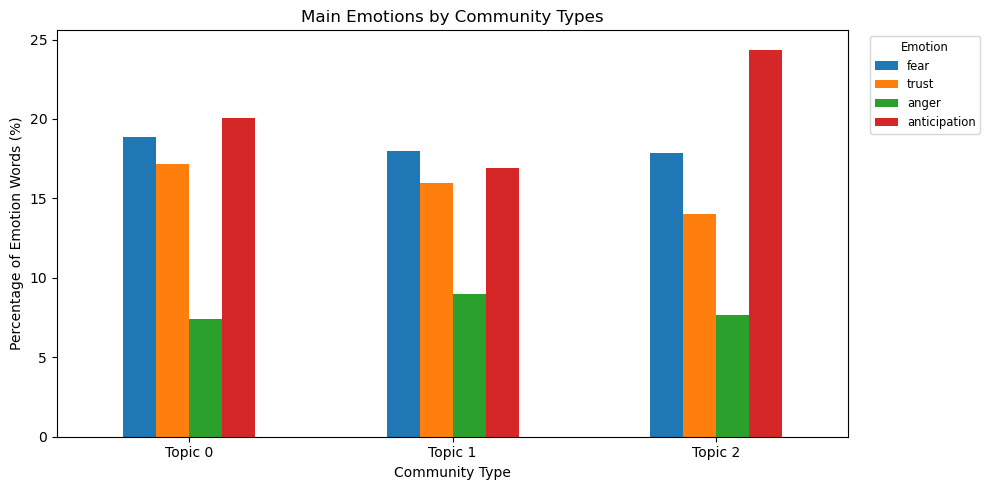

In [46]:
#Code adapted from: https://pypi.org/project/NRCLex/
#Code adapted from: https://colab.research.google.com/github/littlecolumns/ds4j-notebooks/blob/master/upshot-trump-emolex/notebooks/NRC%20Emotional%20Lexicon.ipynb
#Code adapted from: https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot
#Code to detect and display the main emotions within each community grouping
#Map the community to their groupings and the emotions to be collected
dominant_com = {10: "Topic 0", 1: "Topic 1", 7: "Topic 1", 8: "Topic 1", 17: "Topic 1", 151: "Topic 0", 26: "Topic 0", 31: "Topic 1", 33: "Topic 2", 35: "Topic 1", 40: "Topic 1", 42: "Topic 1", 
                       43: "Topic 1", 44: "Topic 0", 51: "Topic 1", 53: "Topic 2", 57: "Topic 0", 58: "Topic 1", 62: "Topic 0", 79: "Topic 0",}
emotion_labels = ["fear", "trust", "anger", "sadness", "joy", "anticipation", "disgust", "surprise",]
group_emotion_counter = defaultdict(Counter)

#Loop through each comment, check if it is a top 20 community and get the topics for that community
for tokens, community, author in combined_list:
    if community in dominant_com:
        group_type = dominant_com[community]

        #Loop through each token and check if the word exists in lexicon
        #If it does then get those words associated with the emotion
        for token in tokens:
            if token in nrc_lexicon:
                affects = nrc_lexicon[token]

                if isinstance(affects, dict):
                    labels = [label for label, value in affects.items() if value]
                else:
                    labels = list(affects)

                #Count the emotions in the current group
                for label in labels:
                    if label in emotion_labels:
                        group_emotion_counter[group_type][label] += 1

#Convert the dictionary of Counters into a DataFrame to allow for plotting to occur
#Calculate the percentage of emotions
emotion_df = pd.DataFrame(group_emotion_counter).fillna(0)
emotion_by_type_percent = (emotion_df / emotion_df.sum()) * 100

#Selecting the target emotions to be featured and outputting the plot
feature_emotions = ["fear", "trust", "anger", "anticipation"]
emotion_source_plot = (emotion_by_type_percent.loc[feature_emotions].T.reindex(["Topic 0", "Topic 1", "Topic 2"]))
ax = emotion_source_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Main Emotions by Community Types")
plt.xlabel("Community Type")
plt.ylabel("Percentage of Emotion Words (%)")
plt.xticks(rotation=0, ha="center")
plt.legend(title="Emotion", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="small", title_fontsize="small")
plt.tight_layout()
plt.show()

In [47]:
#Code adapted from: https://pypi.org/project/NRCLex/
#Code adapted from: https://colab.research.google.com/github/littlecolumns/ds4j-notebooks/blob/master/upshot-trump-emolex/notebooks/NRC%20Emotional%20Lexicon.ipynb
#Code to extract the top words from each emotion
group_words_counter = defaultdict(lambda: defaultdict(Counter))

#Loop through all the text and see that the community is top 20
for tokens, community, author in combined_list:
    if community in dominant_com:
        group_type = dominant_com[community]

        #Loop through each token and check if the word exists in lexicon
        #If it does then get those words associated with the emotion
        for token in tokens:
            if token in nrc_lexicon:
                affects = nrc_lexicon[token]

                if isinstance(affects, dict):
                    labels = [label for label, value in affects.items() if value]
                else:
                    labels = list(affects)

                #Count the emotions in the current group
                for label in labels:
                    if label in emotion_labels:
                        group_words_counter[group_type][label][token] += 1

#Build a list of top emotion words
com_group_top5_words = []

#Loop through each community group type and its respective emotion dictionary
#Extract the top 5 most common words for this specific emotion and group
for group_type, emotions_dict in group_words_counter.items():
    for emotion in emotion_labels:
        top_words = emotions_dict[emotion].most_common(5)
        com_group_top5_words.append({"group_type": group_type, "emotion": emotion, "top_words": top_words})

com_group_top5_words


[{'group_type': 'Topic 1',
  'emotion': 'fear',
  'top_words': [('quarantine', 136),
   ('pandemic', 128),
   ('die', 124),
   ('disease', 109),
   ('bad', 96)]},
 {'group_type': 'Topic 1',
  'emotion': 'trust',
  'top_words': [('good', 134),
   ('hope', 83),
   ('doctor', 65),
   ('medical', 65),
   ('show', 57)]},
 {'group_type': 'Topic 1',
  'emotion': 'anger',
  'top_words': [('disease', 109),
   ('bad', 96),
   ('death', 70),
   ('shit', 55),
   ('lie', 43)]},
 {'group_type': 'Topic 1',
  'emotion': 'sadness',
  'top_words': [('pandemic', 128),
   ('die', 124),
   ('disease', 109),
   ('bad', 96),
   ('kill', 96)]},
 {'group_type': 'Topic 1',
  'emotion': 'joy',
  'top_words': [('good', 134),
   ('hope', 83),
   ('love', 40),
   ('pay', 40),
   ('true', 32)]},
 {'group_type': 'Topic 1',
  'emotion': 'anticipation',
  'top_words': [('ship', 323),
   ('time', 181),
   ('good', 134),
   ('passenger', 108),
   ('worry', 93)]},
 {'group_type': 'Topic 1',
  'emotion': 'disgust',
  'top_

In [48]:
#Code adapted from: https://pypi.org/project/NRCLex/
#Code adapted from: https://colab.research.google.com/github/littlecolumns/ds4j-notebooks/blob/master/upshot-trump-emolex/notebooks/NRC%20Emotional%20Lexicon.ipynb
#Code to detect and display the main emotions within each central user grouping
#Map the central users to their groupings
central_user_grouping = {"reuters.com": "Media", "forbes.com": "Media", "pbsnews.org": "Media", "apnews.com": "Media", "briantylercohen.bsky.social": "Political Commentary", "meidastouch.com": "Political Commentary",
                   "thebulwark.com": "Political Commentary", "atrupar.com": "Political Commentary", "cwebbonline.com": "Political Commentary", "acyn.bsky.social": "Political Commentary",
                   "muellershewrote.com": "Political Commentary", "onestpress.onestnetwork.com": "Political Commentary", "kylegriffin1.bsky.social": "Political Commentary", 
                   "robdelaney.bsky.social": "General", "iamapyriteking.bsky.social": "General", "thev.bsky.social": "Health/Science", "chantzy.bsky.social": "Health/Science",
                   "elizabethjacobs.bsky.social": "Health/Science", "downwithdan.bsky.social": "Health/Science", "sailorrooscout.bsky.social": "Health/Science"}

central_group_words = defaultdict(lambda: defaultdict(Counter))

#Loop through all comments
for tokens, community, author_clean in combined_list:

    #Check if the user belongs to the above groupings
    if author_clean in central_user_grouping:
        broad_group = central_user_grouping[author_clean]

        #Loop through each token and check if the word exists in lexicon
        #If it does then get those words associated with the emotion
        for token in tokens:
            if token in nrc_lexicon:
                affects = nrc_lexicon[token]

                if isinstance(affects, dict):
                    labels = [label for label, value in affects.items() if value]
                else:
                    labels = list(affects)

                #Count the emotions in the current group
                for label in labels:
                    if label in emotion_labels:
                        central_group_words[broad_group][label][token] += 1

#Build a list of top emotion words
central_user_group_top5 = []

#Loop through each community group type and its respective emotion dictionary
#Extract the top 5 most common words for this specific emotion and group
for broad_group, emotions_dict in central_group_words.items():
    for emotion in emotion_labels:
        top_words = emotions_dict[emotion].most_common(5)
        central_user_group_top5.append({"group_type": broad_group, "emotion": emotion, "top_words": top_words})

central_user_group_top5

[{'group_type': 'Health/Science',
  'emotion': 'fear',
  'top_words': [('risk', 11),
   ('case', 11),
   ('quarantine', 10),
   ('disease', 7),
   ('infection', 7)]},
 {'group_type': 'Health/Science',
  'emotion': 'trust',
  'top_words': [('happy', 16),
   ('expert', 5),
   ('recommend', 5),
   ('good', 5),
   ('vigilant', 4)]},
 {'group_type': 'Health/Science',
  'emotion': 'anger',
  'top_words': [('disease', 7),
   ('anxiety', 2),
   ('challenge', 2),
   ('bad', 2),
   ('lose', 1)]},
 {'group_type': 'Health/Science',
  'emotion': 'sadness',
  'top_words': [('case', 11),
   ('disease', 7),
   ('isolation', 4),
   ('isolate', 3),
   ('infectious', 3)]},
 {'group_type': 'Health/Science',
  'emotion': 'joy',
  'top_words': [('happy', 16),
   ('good', 5),
   ('glad', 4),
   ('hope', 3),
   ('grow', 2)]},
 {'group_type': 'Health/Science',
  'emotion': 'anticipation',
  'top_words': [('happy', 16),
   ('ship', 14),
   ('public', 13),
   ('risk', 11),
   ('passenger', 10)]},
 {'group_type':

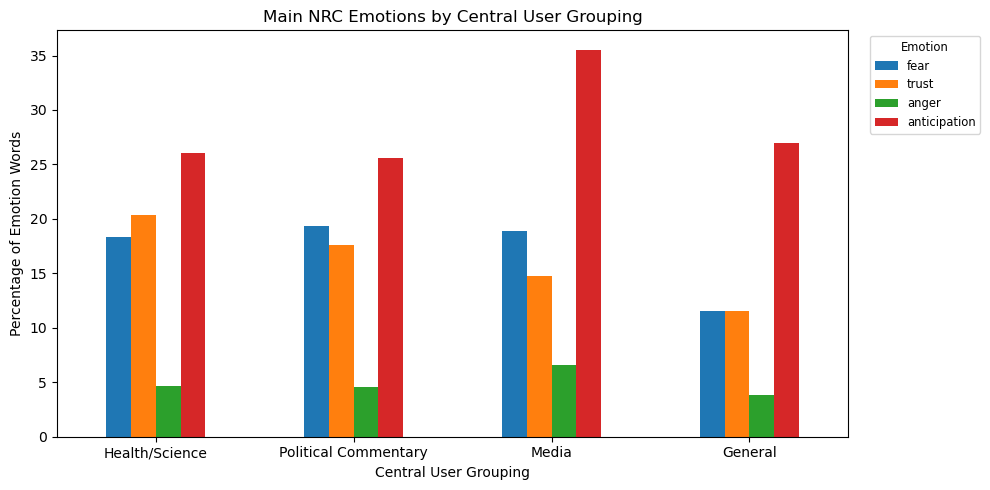

In [49]:
#Code adapted from: https://pypi.org/project/NRCLex/
#Code adapted from: https://colab.research.google.com/github/littlecolumns/ds4j-notebooks/blob/master/upshot-trump-emolex/notebooks/NRC%20Emotional%20Lexicon.ipynb
#Code adapted from: https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot
#Store the emotions by central users
central_user_emotion_counts = defaultdict(Counter)

#Convert individual word counts into total emotion counts for each central user group
for broad_group, emotions_dict in central_group_words.items():
    for emotion, tokens_counter in emotions_dict.items():
        central_user_emotion_counts[broad_group][emotion] = sum(tokens_counter.values())

#Convert the dictionary of Counters into a DataFrame to allow for plotting to occur
#Calculate the percentage of emotions
emotion_df = pd.DataFrame(central_user_emotion_counts).fillna(0)
emotion_by_type_percent = (emotion_df / emotion_df.sum()) * 100

#Selecting the target emotions to be featured and outputting the plot
emotion_source_plot = emotion_by_type_percent.loc[feature_emotions].T
ax = emotion_source_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Main NRC Emotions by Central User Grouping")
plt.xlabel("Central User Grouping")
plt.ylabel("Percentage of Emotion Words")
plt.xticks(rotation=0, ha="center")  # Clean horizontal labels for your 3 groups
plt.legend(title="Emotion", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="small", title_fontsize="small")
plt.tight_layout()
plt.show()